In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
import seaborn as sns
from math import ceil
import cartopy.crs as ccrs
from matplotlib import pyplot as plt
from libpysal.graph import Graph
from matplotlib.gridspec import GridSpec
from HANZEanalytics.eda.plots import get_europe_canvas, save_fig, area_to_gif

In [2]:
root = Path.cwd().parent

events = pd.read_csv(Path(root, "data", "HANZE_events").with_suffix(".csv"))
regions = gpd.read_file(Path(root, "data", "Regions_v2021_simplified.zip"))
floods = gpd.read_file(Path(root, "data", "HANZE_floods_regions_2021.zip"))

events = events.astype({"ID": int,"Year": int})
events[["Start date", "End date"]] = events[["Start date", "End date"]].apply(pd.to_datetime)
floods = floods.astype({"ID": int, "Year": int, "Start_M": int, "Start_Y": int, "End_M": int, "End_Y": int})

events = events[events["Year"] >= 2000]
floods = floods[floods["Year"] >= 2000]

affected_regions = "Regions affected (v2021)"
events[affected_regions] = events[affected_regions].str.split(";")

regions = regions.set_index("Code")
regions = regions.to_crs(epsg=4326)

plot_condition = True

In [3]:
years = floods["Year"].drop_duplicates().sort_values().to_list()
if plot_condition and False:
    ncol = 2
    nrow = ceil(len(years) / ncol)
    fig = plt.figure(figsize=(18, nrow * 7))
    gs = GridSpec(nrows=nrow, ncols=ncol, figure=fig,
                       wspace=0.01, hspace=0.15)

    for idx,year in enumerate(years):
        row, col = divmod(idx, ncol)
        ax = fig.add_subplot(gs[row, col], projection=ccrs.epsg(floods.crs.to_epsg()))
        ax, crs = get_europe_canvas(ax=ax)
        ax.set_title(str(year), fontsize = 13, fontweight='bold', pad=8)
        data = floods[floods["Year"] == year]
        data.to_crs(crs).plot(ax=ax, color="red", zorder=4, transform=ccrs.PlateCarree())
    fig.set_constrained_layout(True)
    save_fig("affected_regions")


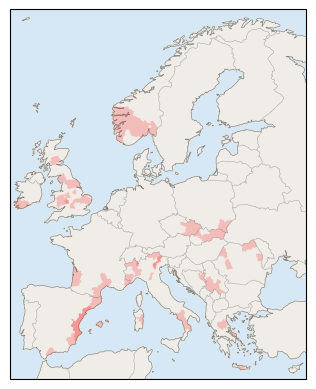

In [ ]:
if plot_condition:
    frames = area_to_gif(floods, years, title = "")
    frames[0].save(Path(root, "assets", "area_single.gif"), save_all=True, append_images=frames[1:],duration=800,loop=0)

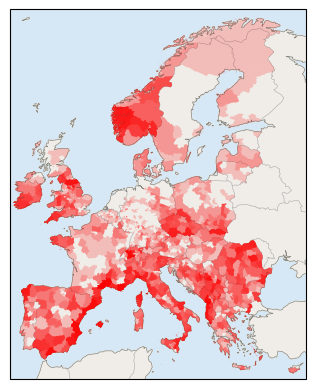

In [ ]:
if plot_condition:
    frames = area_to_gif(floods, years, cummulative=True, title = "")
    frames[0].save(Path(root, "assets", "area_cummulative.gif"), save_all=True, append_images=frames[1:],duration=800,loop=0)

<Axes: ylabel='Count'>

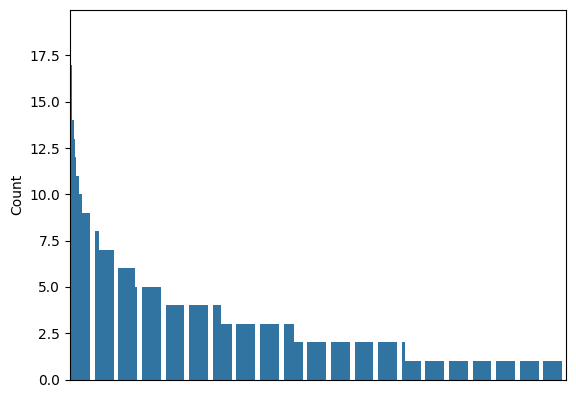

In [6]:
(events
 .explode(affected_regions)[affected_regions]
 .value_counts()
 .rename_axis("Region")
 .reset_index(name="Count")
 .sort_values("Count", ascending=False)
 .pipe(lambda df: (
     ax := sns.barplot(data=df, y="Count", x="Region"),
     ax.set_xticks([]),
     ax.set_xlabel("")
 )[0]))

In [7]:
queen = Graph.build_contiguity(regions["geometry"], rook=False)
queen

<Graph of 1443 nodes and 7424 nonzero edges (32 components, 22 isolates) indexed by
 ['AD000', 'AL011', 'AL012', 'AL013', 'AL014', ...]>

/tmp/ipykernel_107062/4154001464.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = regions.geometry.centroid


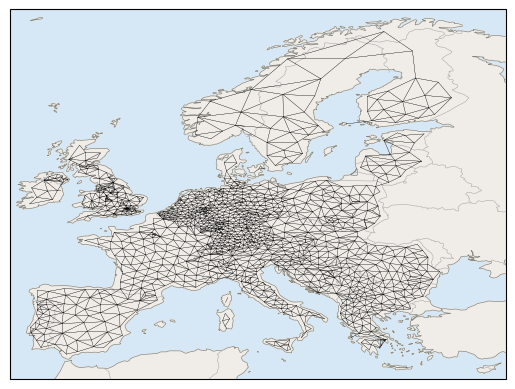

In [8]:
fig, ax = plt.subplots(subplot_kw={"projection": ccrs.PlateCarree()})
ax, crs = get_europe_canvas(ax=ax)

centroids = regions.geometry.centroid

# draw edges
for i, neighbors in queen.neighbors.items():
    for j in neighbors:
        x = [centroids[i].x, centroids[j].x]
        y = [centroids[i].y, centroids[j].y]

        ax.plot(
            x, y,
            color="black",
            linewidth=0.15,
            transform=ccrs.PlateCarree()
        )
save_fig("adjacency")